# A Simple Script to Integrate Differential Equations
## Function import

<font size="6"> Part II</font>

# Preamble

## Prerequisites

- Ordinary differential equations
- ODE solvers
- Numerical solutions

## Outcomes

- Implement a mathematical model
- Set up and initialise a model
- Run simulations

Data can be collected in different ways. Depending on the time scale of the observed variables, the approach to model any findings differ.

If on the time scale of observation data can be considered static, a statistical model is a good approach. One measures various instances and checks the distribution of the values. 

If on the time scale of observation data are changing, i.e. time-dependent, a dynamical model is the appropriate approach. A key theory behind temporal changes are the ordinary differential equations. There is an established theory, originating in the theoretical physics of work by e.g. Leibniz and Newton. 

In life science practice, we often do not need the details of the theory behind the equations but we need the computational implementation and the simulation of the models. The numerical output of the simulations then allows comparison with experimental or real-life data. 

There are three main ingredients to achieve a dynamical systems simulation: 

- The abstract model
- Numerical values
- Code to "run" the model

Let us start by looking at a minimal code that achieves this. 

## Rate Equation Definition

The simplest model that can produce long-term time-dependent output is the harmonic oscillator. In physics it is often introduced as two equations that describe the motion of a pendulum. 

In mathematical notation:

$$ \frac{dX}{dt} = - Y$$
$$ \frac{dY}{dt} =   X$$

There are two equations corresponding to two variables. These variables correspond to observable quantities. The left-hand side are rates: they express "how fast the variable is changing". The right-hand side is the law or function according to which that rate is calculated. It is extremely simple here: the rate of change of $X$ is obtained from minu the current quantity of $Y$ and the rate of change of $Y$ is obtained from the current quantity of $X$. 

In the physical description of the pendulum, $X$ is the position of the pendulum expressed as the deviation from the resting point. $Y$ is the veloocity of the centre of mass of the pendulum. A positive displacement in $X$ will lead to an increase in velocity (second equation) but the increased velocity will pull the position back to the centre (first equation). The model is strongly idealised. In particular, there is only one direction in which the movement is possible and there is no friction or damping

Here is the function that implements the model.

In [2]:
def model(t, variables):
    """Harmonic Oscillator"""
    
    X, Y = variables
    
    dXdt = - Y
    dYdt = + X
    
    return [dXdt, dYdt]

The function expects an input of time $t$ and $variables$. Both will be continuosly updated to simulate that time passes and to feed the current state of the model. Time is simply a real number and the $variables$ is a vector that has as many items as there are equations. 

The function unpacks the variables, and calculates the two incremental rates from the given function and returns them. With the calculated rate of change, new values of the variables are calculated (outside of the function) and the updated values are passed back to the function with the next time point. This process is then repeated for as many time points as required.


This repetition of the same process, over and over again, is called an iteration. As a result one gets the variales as a function of time.

Here is the SciPy function that does the iteration and plots the result. 

## Integrate with ```solve_ivp``` and Plot Result

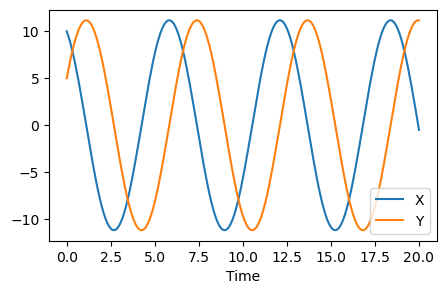

In [4]:
from scipy.integrate   import solve_ivp

solution = solve_ivp(model, (0, 20), (10, 5), max_step=0.1)

from matplotlib.pyplot import subplots

fig, ax = subplots(figsize=(5, 3))

ax.plot(solution.t, solution.y.T, label=["X", "Y"]);
ax.set_xlabel('Time');
ax.legend();

The function ```solve_ivp``` through an array of time points and calculates the variables as a function of time. The variables are stored in the ```solution``` which contains them both (```solution.Y```) along the corresponding time points ```solution.t```.

The ```solve_ivp``` function call needs the following: 1. A handle to the model that should be used. 2. The time range (start and end time) over which to the the simulatiom. 3. The intial values of all variables. Without these values the simulation cannot start. Incidentally, the function name derives from *solve initial value problem*. The keyword argument ```max_step``` limits the time steps during the iteration. A smooth output is obtained if the steps are kept small. (Check what happens, when the number is increased).

Here is a more explizit but otherwise identical version:

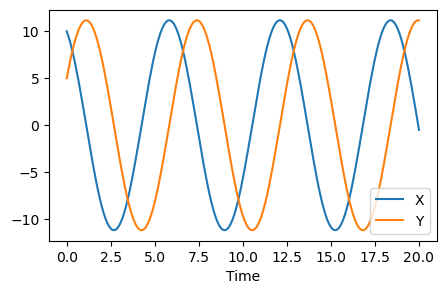

In [5]:
from scipy.integrate   import solve_ivp


t_start, t_stop = 0, 20
X_init, Y_init  = 10, 5

solution = solve_ivp(model, (t_start, t_stop), (X_init, Y_init ), max_step=0.1)


from matplotlib.pyplot import subplots

fig, ax = subplots(figsize=(5, 3))

ax.plot(solution.t, solution.y.T, label=["X", "Y"]);
ax.set_xlabel('Time');
ax.legend();

Interpretation of the simulation: an undamped pendulum oscillates periodically. Position and Velocity show identical waveforms but are phase-delayed with respect to each other.

You can modify the model and see what impact changes in the settings make. 

## Integrate with ```odeint```

SciPy package has another solver for numerical integration called ```odeint```. Here is how it can be used to get a similar result:

In [22]:
def model_2(variables, t):
    """Harmonic Oscillator"""
    
    X, Y = variables
    
    dXdt = - Y
    dYdt = + X
    
    return [dXdt, dYdt]

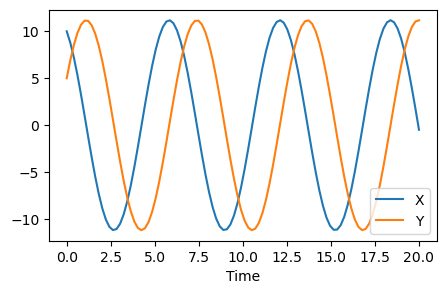

In [24]:
from scipy.integrate   import odeint
from numpy import linspace

t_start, t_stop = 0, 20
time = linspace(t_start, t_stop, 100)

X_init, Y_init  = 10, 5

variables = odeint(model_2, (X_init, Y_init), time,                hmax=0.1)

from matplotlib.pyplot import subplots

fig, ax = subplots(figsize=(5, 3))

ax.plot(time, variables, label=["X", "Y"]);
ax.set_xlabel('Time');
ax.legend();

It is quite similar to ```ivp_solve``` but expects the ```time``` and ```variables``` arguments in reversed order. It means that they cannot be used with the same model function. 

Which solver to use and the details of the iteration algorithms are the subject of *[numerical integration](https://en.wikipedia.org/wiki/Numerical_integration)*.